In [197]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [198]:
df = pd.read_csv("paddydataset.csv")
#df.info()

In [199]:
df=df.drop(columns=['Trash(in bundles)'])

In [200]:
#check for any Null Values
df.isna().sum()

Hectares                              0
Agriblock                             0
Variety                               0
Soil Types                            0
Seedrate(in Kg)                       0
LP_Mainfield(in Tonnes)               0
Nursery                               0
Nursery area (Cents)                  0
LP_nurseryarea(in Tonnes)             0
DAP_20days                            0
Weed28D_thiobencarb                   0
Urea_40Days                           0
Potassh_50Days                        0
Micronutrients_70Days                 0
Pest_60Day(in ml)                     0
30DRain( in mm)                       0
30DAI(in mm)                          0
30_50DRain( in mm)                    0
30_50DAI(in mm)                       0
51_70DRain(in mm)                     0
51_70AI(in mm)                        0
71_105DRain(in mm)                    0
71_105DAI(in mm)                      0
Min temp_D1_D30                       0
Max temp_D1_D30                       0


In [201]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

summary = numeric_df.agg(['min', 'max']).T   # rows = columns, cols = ['min','max']
summary.columns = ['min', 'max']             # nicer column names

#print(summary)          # standard DataFrame print
# or, in Jupyter, just:
summary

,min,max
Hectares,1.00,6.00
Seedrate(in Kg),25.00,150.00
LP_Mainfield(in Tonnes),12.50,75.00
Nursery area (Cents),20.00,120.00
LP_nurseryarea(in Tonnes),1.00,6.00
DAP_20days,40.00,240.00
Weed28D_thiobencarb,2.00,12.00
Urea_40Days,27.13,162.78
Potassh_50Days,10.38,62.28
Micronutrients_70Days,15.00,90.00


In [202]:
#Encoding Categorical columns - Agriblock, Variety, Soil Types,Nursery
import pandas as pd

cat_cols = ["Agriblock", "Variety", "Soil Types", "Nursery"]

for col in cat_cols:
    df[col] = df[col].astype("category")
    df[col] = df[col].cat.codes+1

In [203]:
import numpy as np
import pandas as pd

cols = [
    "Wind Direction_D1_D30",
    "Wind Direction_D31_D60",
    "Wind Direction_D61_D90",
    "Wind Direction_D91_D120",
]

# 1. Get all unique directions across the 4 columns
unique_dirs = np.unique(df[cols].values.ravel())

# 2. Create codes for these unique directions
codes, uniques = pd.factorize(unique_dirs)

codes = codes + 1

# 3. Build mapping dict: direction -> code
dir_to_code = dict(zip(uniques, codes))

# 4. Apply the same mapping to all 4 columns
df[cols] = df[cols].replace(dir_to_code)

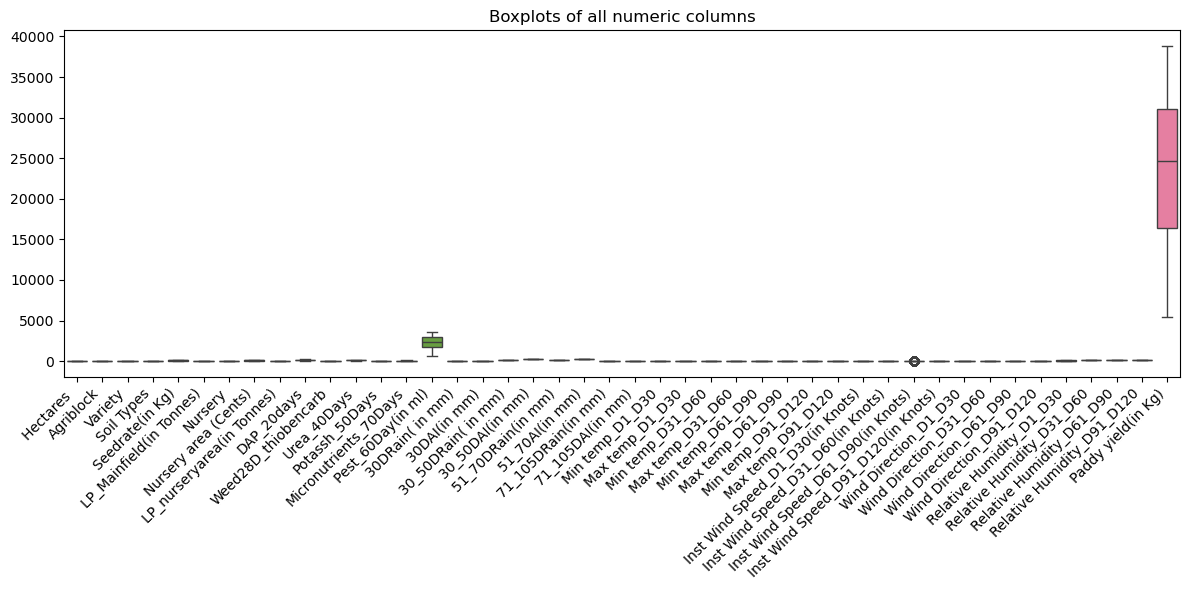

In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only numeric columns
num_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12, 6))  # widen if many columns
sns.boxplot(data=num_df)
plt.xticks(rotation=45, ha="right")
plt.title("Boxplots of all numeric columns")
plt.tight_layout()
plt.show()

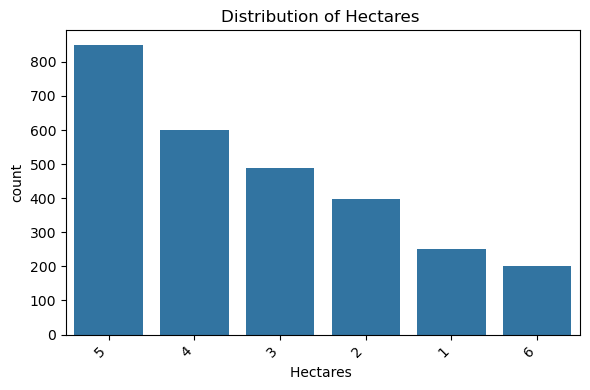

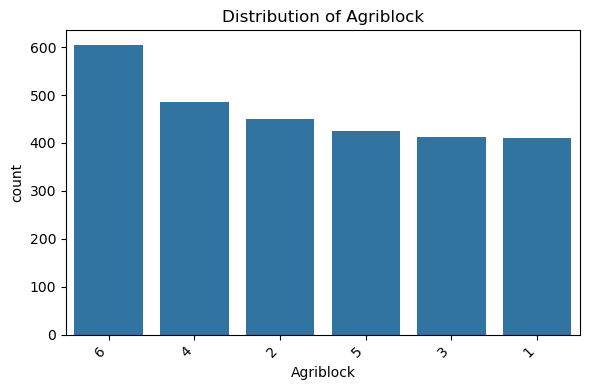

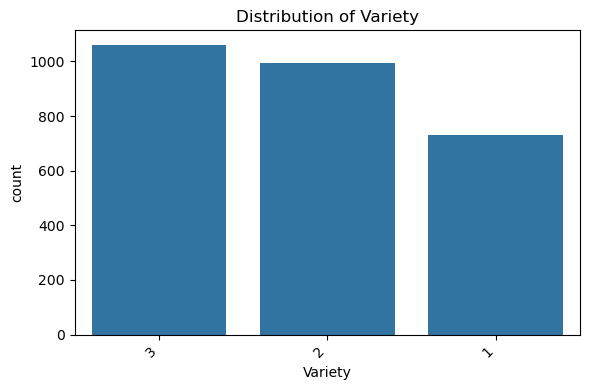

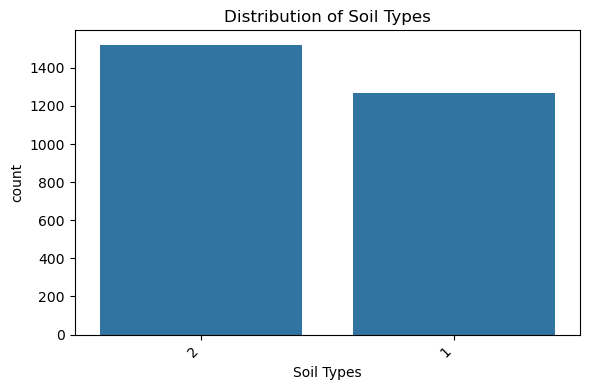

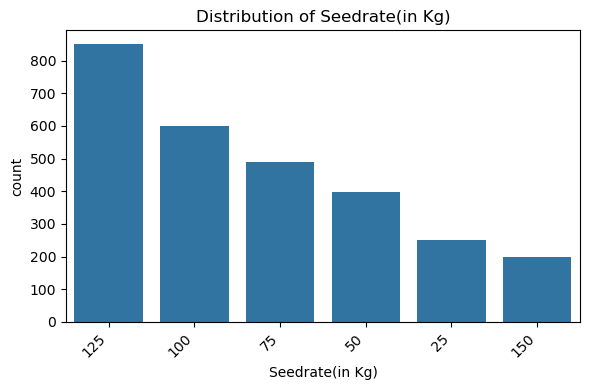

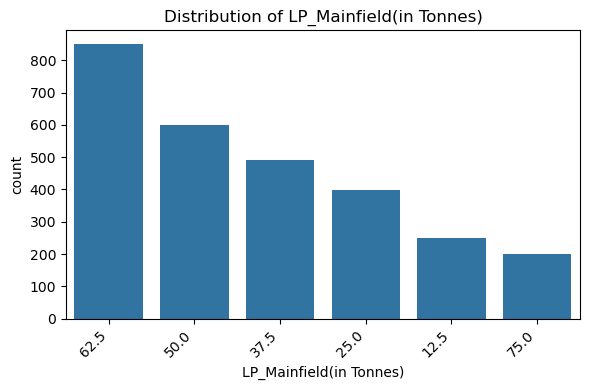

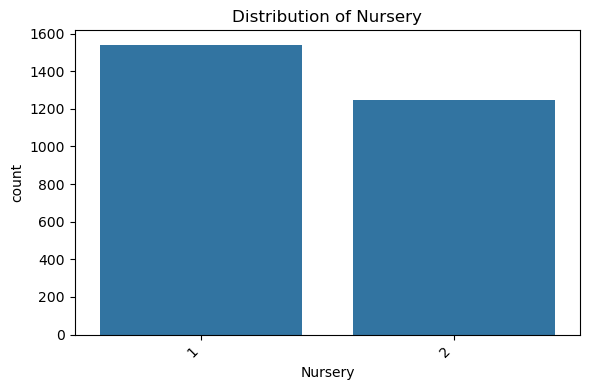

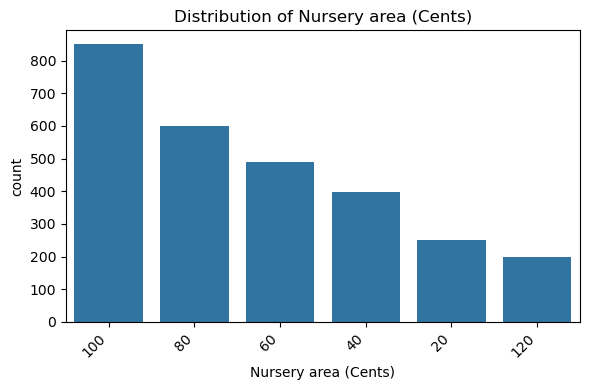

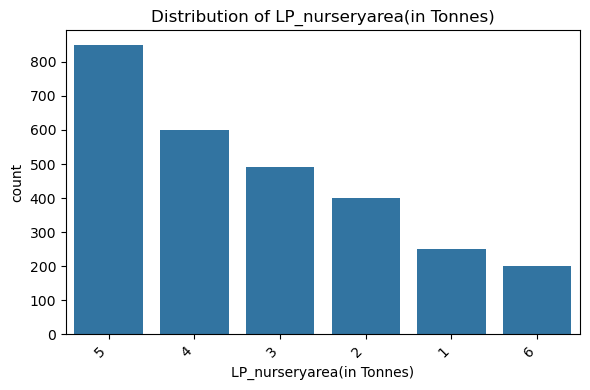

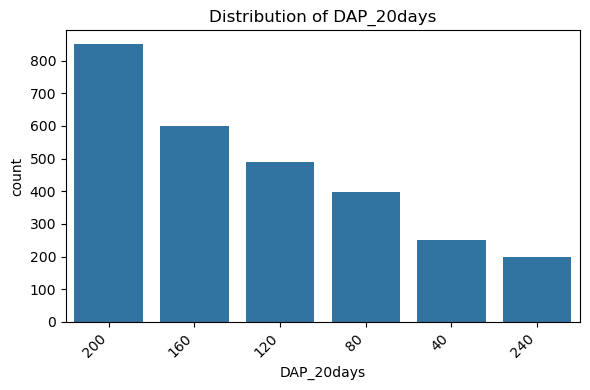

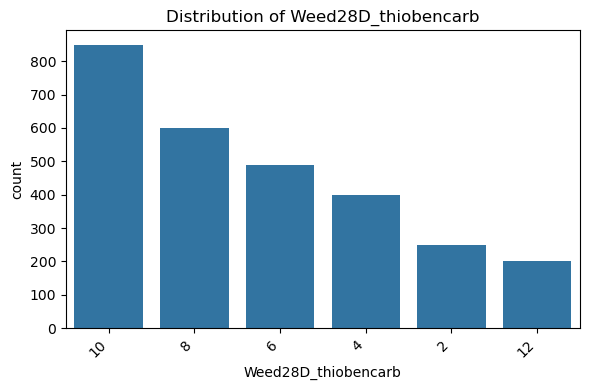

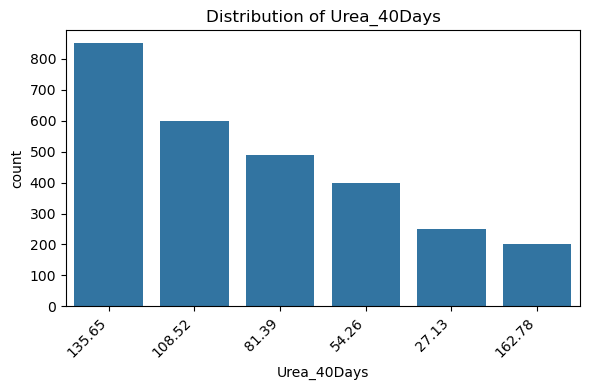

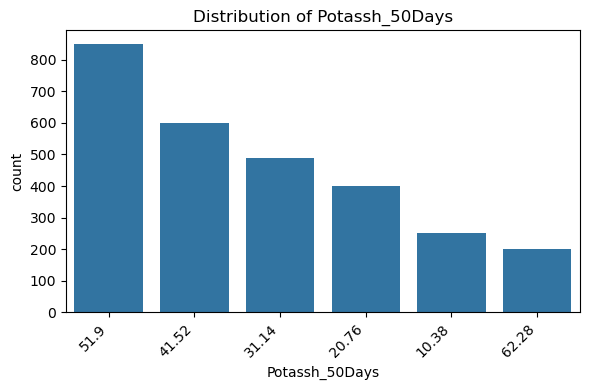

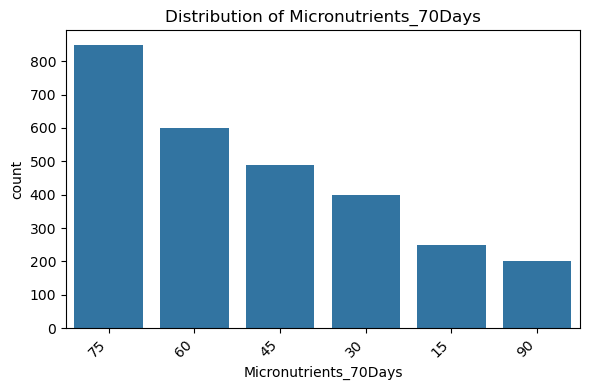

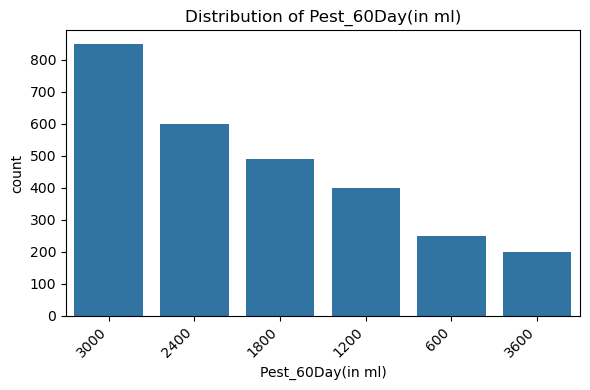

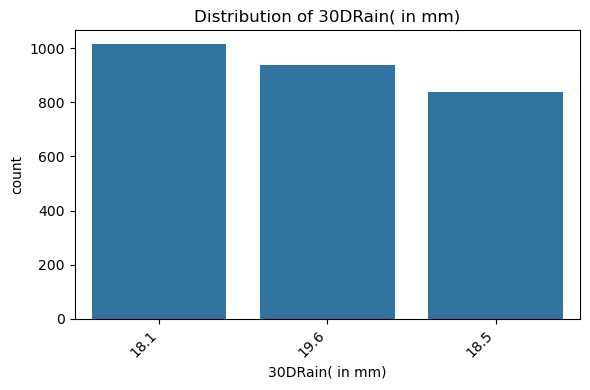

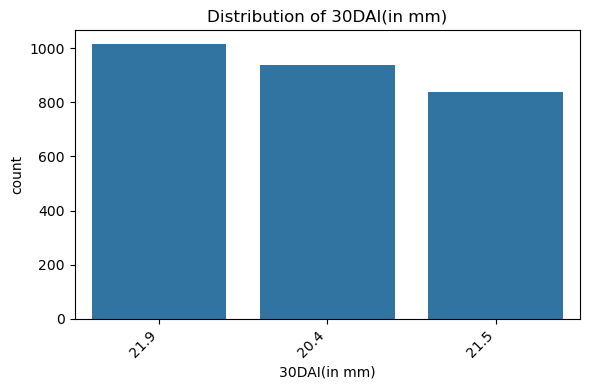

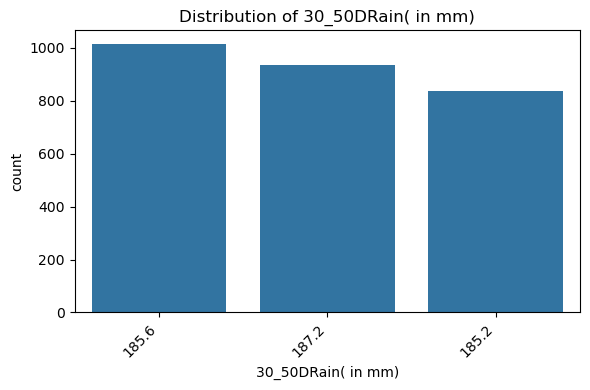

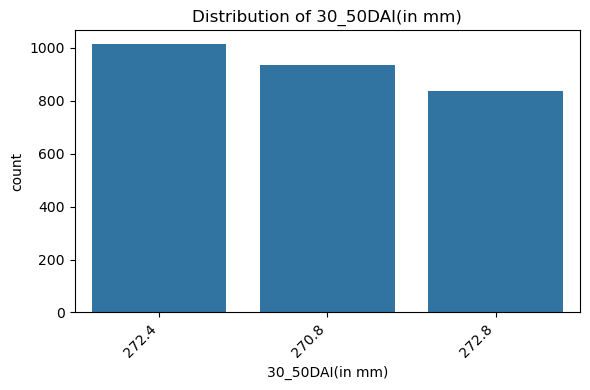

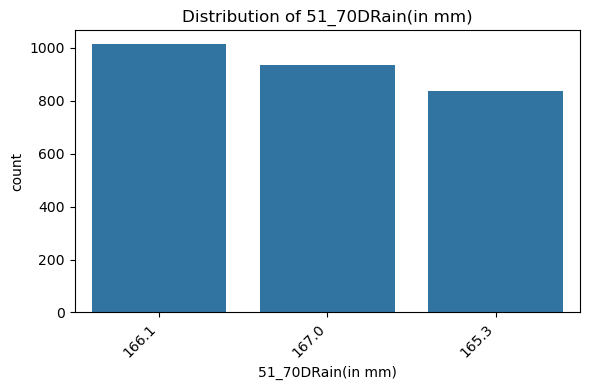

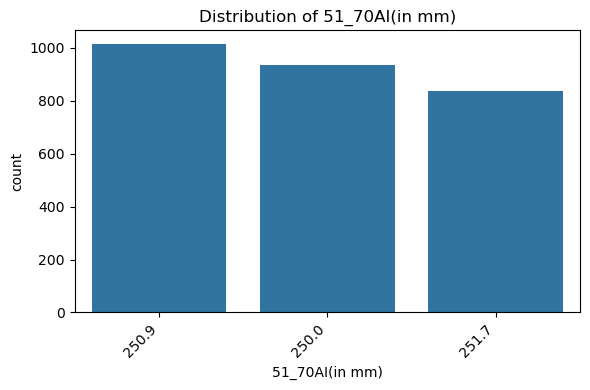

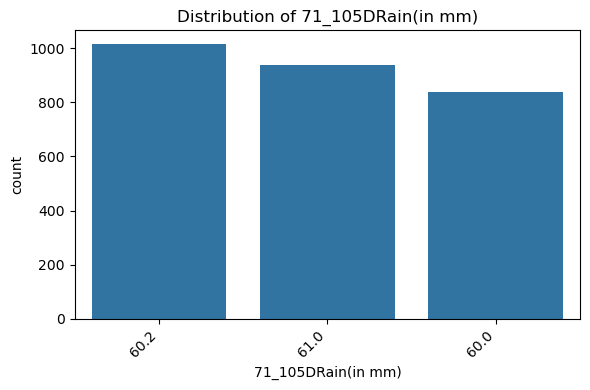

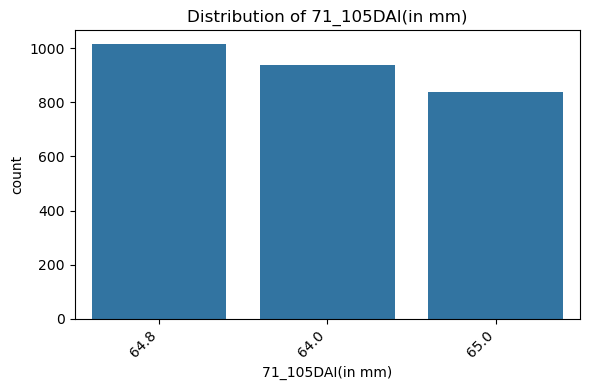

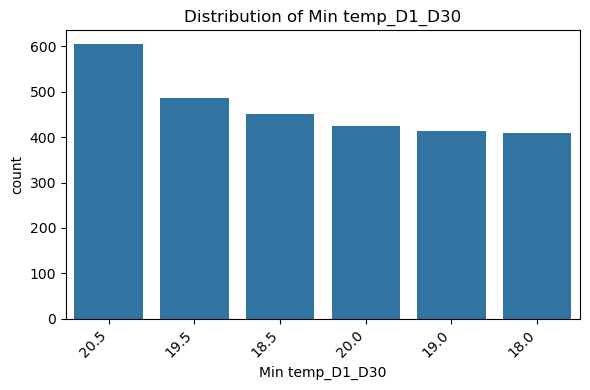

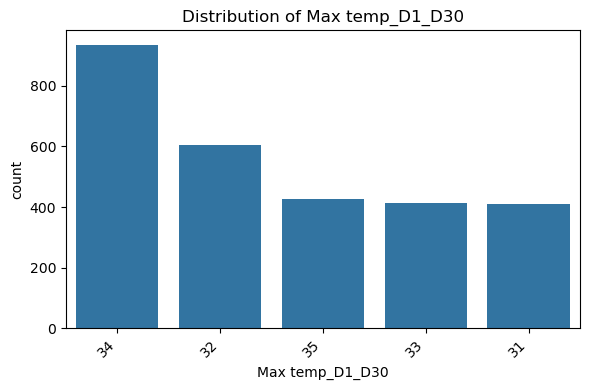

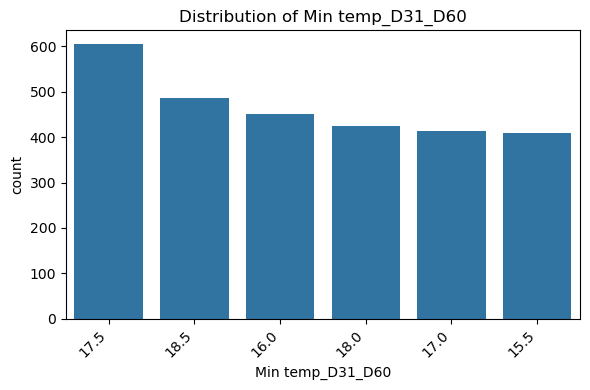

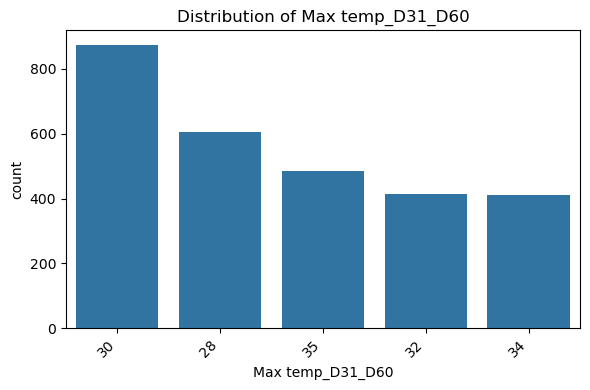

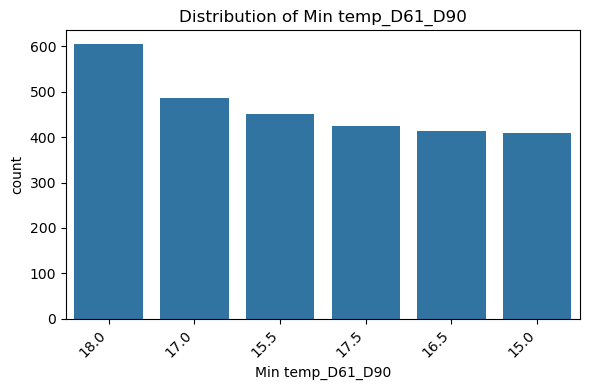

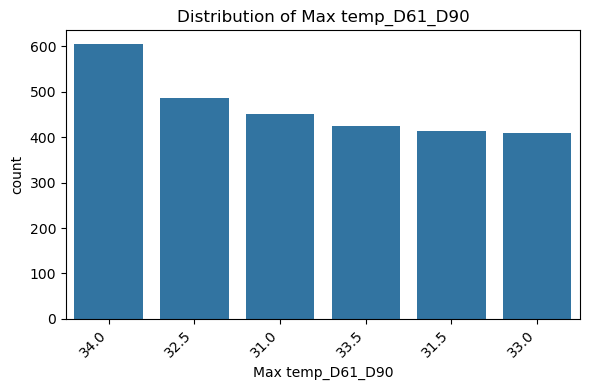

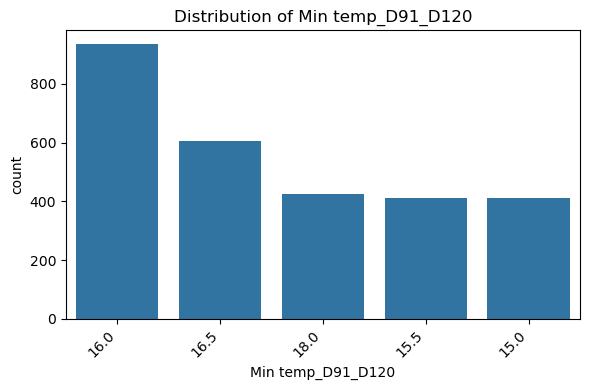

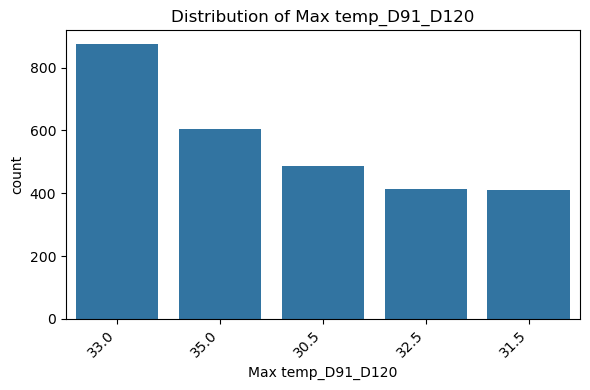

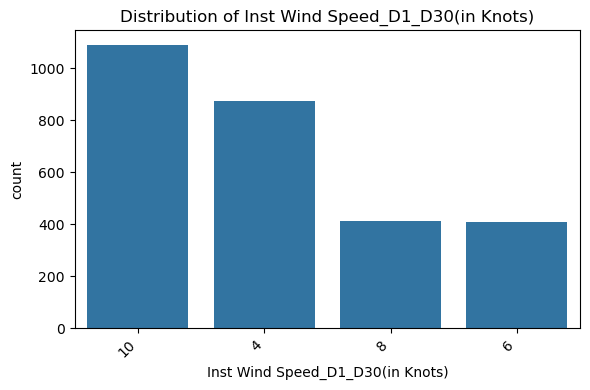

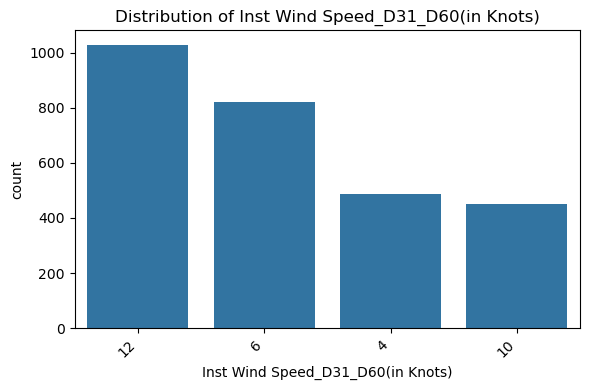

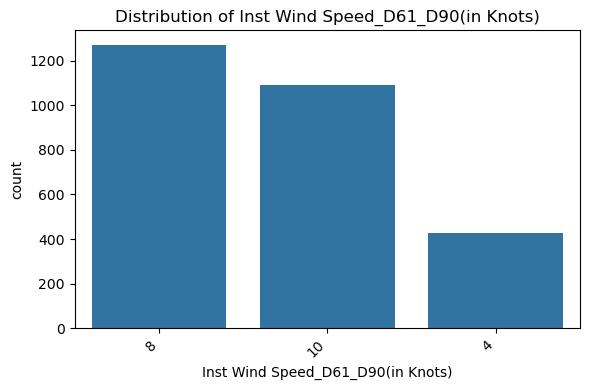

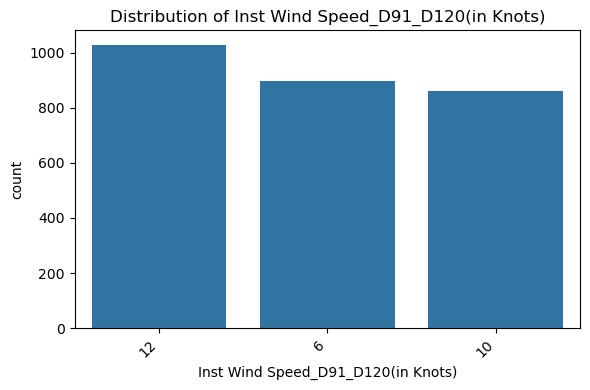

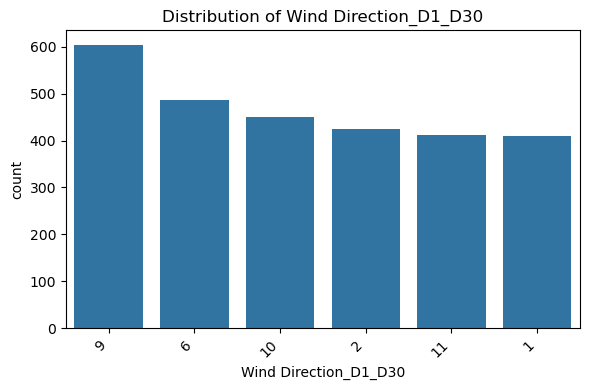

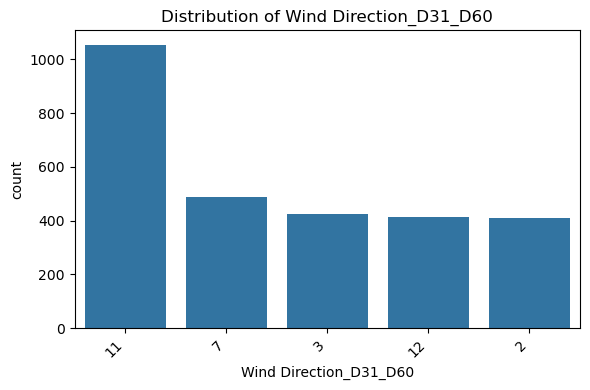

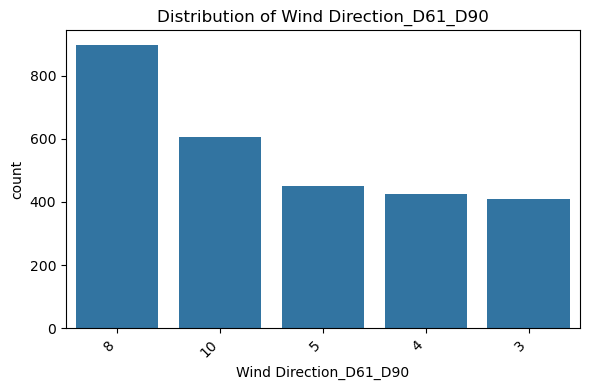

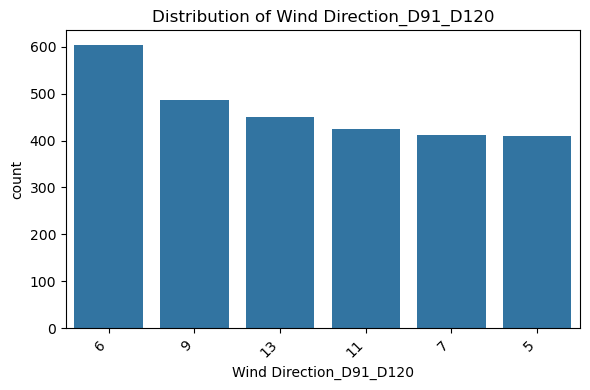

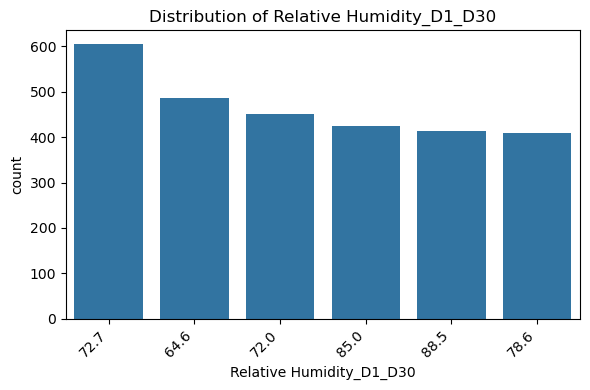

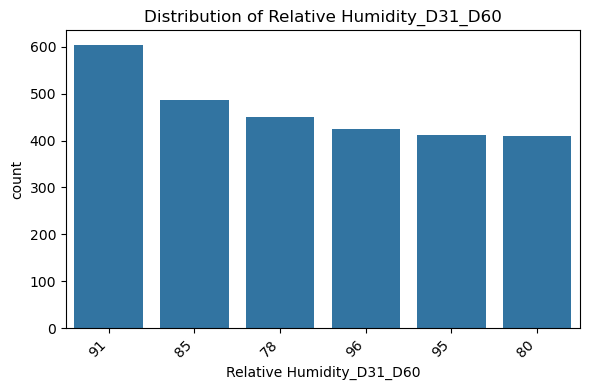

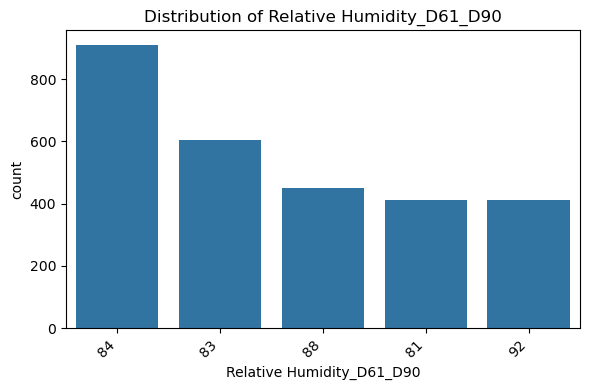

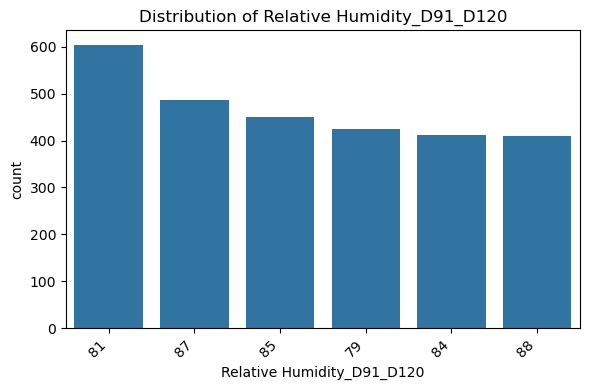

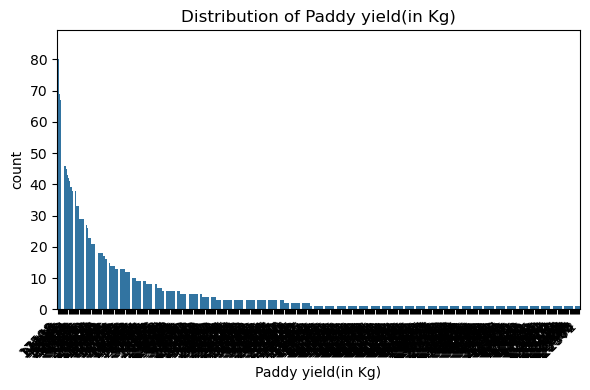

In [205]:
#Check for narmality before
import matplotlib.pyplot as plt
import seaborn as sns
for c in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=c, order=df[c].value_counts().index)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Distribution of {c}")
    plt.tight_layout()
    plt.show()

In [206]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer

# df is your DataFrame
# If you have a target column, exclude it:
target_col = "Paddy yield(in Kg)"   # change or set to None if no target

if target_col in df.columns:
    feature_cols = df.columns.drop(target_col)
else:
    feature_cols = df.columns

X = df[feature_cols].values
print (X)
pt = PowerTransformer(method="yeo-johnson", standardize=False)  # works with negatives [web:634][web:635][web:638][web:642]
X_trans = pt.fit_transform(X)

df_trans = df.copy()
df_trans[feature_cols] = X_trans

[[ 6.  2.  1. ... 78. 88. 85.]
 [ 6.  4.  3. ... 85. 84. 87.]
 [ 6.  5.  2. ... 96. 84. 79.]
 ...
 [ 1.  1.  2. ... 80. 92. 88.]
 [ 1.  2.  1. ... 78. 88. 85.]
 [ 1.  4.  2. ... 85. 84. 87.]]


In [207]:
df_trans.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Inst Wind Speed_D91_D120(in Knots),Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Paddy yield(in Kg)
0,9.801698,1.825719,1.090638,1.147058,346.493516,155.447272,0.424326,267.324951,9.801698,600.389972,...,65.696776,11.415332,16.750424,3.597542,1.685485,3.434051,11871.537490,0.139548,3.536509e+08,35028
1,9.801698,3.470714,3.634975,2.521839,346.493516,155.447272,0.526756,267.324951,9.801698,600.389972,...,25.748331,6.648335,9.814521,5.257000,1.550395,3.366399,14483.037067,0.139548,3.946363e+08,35412
2,9.801698,4.255614,2.314926,1.147058,346.493516,155.447272,0.424326,267.324951,9.801698,600.389972,...,92.683523,2.107201,3.691340,2.992607,1.625676,3.536278,19199.183106,0.139548,2.504750e+08,36300
3,9.801698,2.663003,1.090638,2.521839,346.493516,155.447272,0.526756,267.324951,9.801698,600.389972,...,25.748331,12.631437,18.581778,5.257000,1.451080,3.560888,18738.839415,0.139548,3.344619e+08,35016
4,9.801698,5.022039,3.634975,1.147058,346.493516,155.447272,0.424326,267.324951,9.801698,600.389972,...,92.683523,10.208064,16.750424,6.271272,1.387611,3.440053,16961.136672,0.139548,2.817828e+08,34044


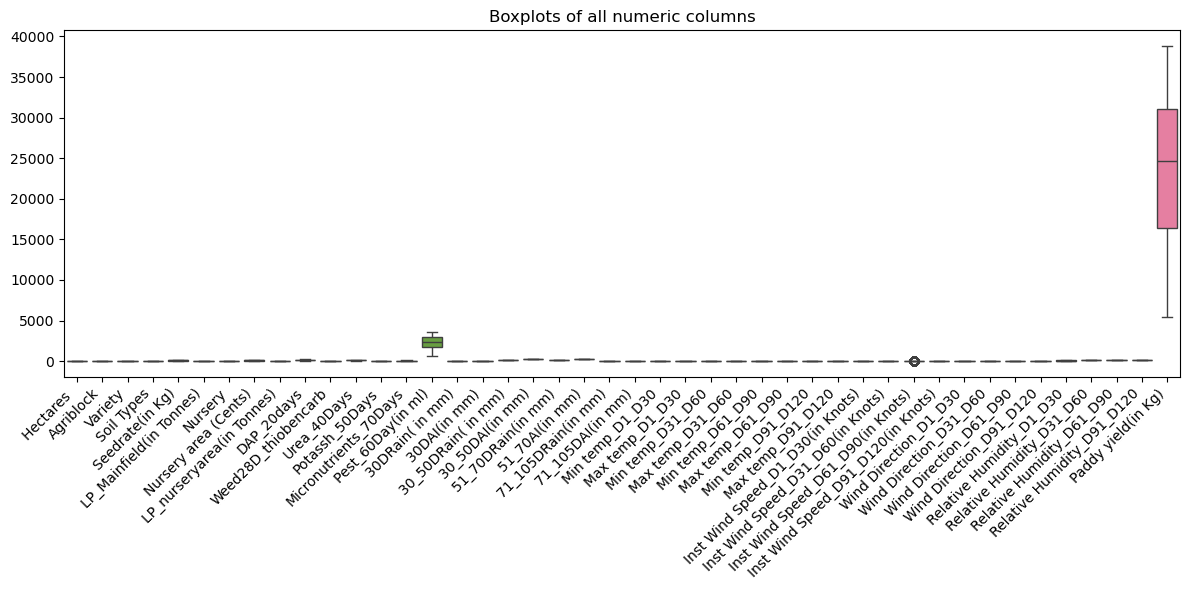

In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only numeric columns
num_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12, 6))  # widen if many columns
sns.boxplot(data=num_df)
plt.xticks(rotation=45, ha="right")
plt.title("Boxplots of all numeric columns")
plt.tight_layout()
plt.show()

In [209]:
import pandas as pd
from sklearn.model_selection import train_test_split

# df is your DataFrame
target_col = "Paddy yield(in Kg)"  # change to your real target name

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [210]:
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=None,        # you can tune these
    min_samples_split=2,
    min_samples_leaf=1,
)

tree.fit(X_train, y_train)

feature_importances = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importances.sort_values())

Hectares                              0.000000
Micronutrients_70Days                 0.000000
Potassh_50Days                        0.000000
Urea_40Days                           0.000000
Seedrate(in Kg)                       0.000000
Nursery area (Cents)                  0.000000
LP_Mainfield(in Tonnes)               0.000000
DAP_20days                            0.000000
30DRain( in mm)                       0.000001
30_50DRain( in mm)                    0.000002
30_50DAI(in mm)                       0.000002
Wind Direction_D1_D30                 0.000002
Wind Direction_D31_D60                0.000003
Min temp_D1_D30                       0.000004
Max temp_D91_D120                     0.000004
71_105DRain(in mm)                    0.000005
Relative Humidity_D61_D90             0.000005
Max temp_D31_D60                      0.000006
30DAI(in mm)                          0.000006
Inst Wind Speed_D1_D30(in Knots)      0.000007
Inst Wind Speed_D61_D90(in Knots)     0.000008
71_105DAI(in 

In [211]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(
    estimator=tree,
    prefit=True,
    threshold="median"   # keeps ~half the features; adjust as needed
)

X_train_sel = selector.transform(X_train)
X_test_sel  = selector.transform(X_test)

print("Original features:", X_train.shape[1])
print("Selected features:", X_train_sel.shape[1])


Original features: 43
Selected features: 22


In [212]:
from sklearn.metrics import mean_squared_error, r2_score

tree_sel = DecisionTreeRegressor(random_state=42)
tree_sel.fit(X_train_sel, y_train)

y_pred = tree_sel.predict(X_test_sel)

mse = mean_squared_error(y_test, y_pred)   # no 'squared' argument
rmse = np.sqrt(mse)


r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 904.5362212966735
R2: 0.9899126332286654


In [ ]:
with open("HousingPrice.pkl", "wb") as f:
    pickle.dump(pipe, f)

print("Model saved successfully!")

In [213]:
df.head(1)

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Inst Wind Speed_D91_D120(in Knots),Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Paddy yield(in Kg)
0,6,2,1,1,150,75.0,1,120,6,240,...,10,10,11,5,13,72.0,78,88,85,35028


In [214]:
#Test the model
sample_dict = {
    "Hectares ": 6.0,
    "Agriblock": 4.0,
    "Variety": 2.0,
    "Soil Types": 1.0,
    "Seedrate(in Kg)": 150.0,
    "LP_Mainfield(in Tonnes)": 75.0,
    "Nursery": 1.0,
    "Nursery area (Cents)": 120.0,
    "LP_nurseryarea(in Tonnes)": 6.0,
    "DAP_20days": 240.0,
    "Weed28D_thiobencarb": 12.0,
    "Urea_40Days": 162.78,
    "Potassh_50Days": 62.28,
    "Micronutrients_70Days": 90.0,
    "Pest_60Day(in ml)": 3600.0,
    "30DRain( in mm)": 19.6,
    "30DAI(in mm)": 20.4,
    "30_50DRain( in mm)": 187.2,
    "30_50DAI(in mm)": 270.8,
    "51_70DRain(in mm)": 167.0,
    "51_70AI(in mm)": 250.0,
    "71_105DRain(in mm)": 61.0,
    "71_105DAI(in mm)": 64.0,
    "Min temp_D1_D30": 19.5,
    "Max temp_D1_D30": 34.0,
    "Min temp_D31_D60": 18.5,
    "Max temp_D31_D60": 35.0,
    "Min temp_D61_D90": 17.0,
    "Max temp_D61_D90": 32.5,
    "Min temp_D91_D120": 16.0,
    "Max temp_D91_D120": 30.5,
    "Inst Wind Speed_D1_D30(in Knots)": 10.0,
    "Inst Wind Speed_D31_D60(in Knots)": 4.0,
    "Inst Wind Speed_D61_D90(in Knots)": 10.0,
    "Inst Wind Speed_D91_D120(in Knots)": 6.0,
    "Wind Direction_D1_D30": 6.0,
    "Wind Direction_D31_D60": 7.0,
    "Wind Direction_D61_D90": 8.0,
    "Wind Direction_D91_D120": 9.0,
    "Relative Humidity_D1_D30": 64.6,
    "Relative Humidity_D31_D60": 85.0,
    "Relative Humidity_D61_D90": 84.0,
    "Relative Humidity_D91_D120": 87.0,
}
    
sample_df = pd.DataFrame([sample_dict])

# If you used SelectFromModel:
sample_sel = selector.transform(sample_df)
sample_pred = tree_sel.predict(sample_sel)[0]
print("Predicted value:", sample_pred)

Predicted value: 37564.0


In [215]:
row = df.head(10).iloc[7]

for col, val in row.items():
    print(f"{col}: {val}")

Hectares : 6.0
Agriblock: 4.0
Variety: 2.0
Soil Types: 1.0
Seedrate(in Kg): 150.0
LP_Mainfield(in Tonnes): 75.0
Nursery: 1.0
Nursery area (Cents): 120.0
LP_nurseryarea(in Tonnes): 6.0
DAP_20days: 240.0
Weed28D_thiobencarb: 12.0
Urea_40Days: 162.78
Potassh_50Days: 62.28
Micronutrients_70Days: 90.0
Pest_60Day(in ml): 3600.0
30DRain( in mm): 19.6
30DAI(in mm): 20.4
30_50DRain( in mm): 187.2
30_50DAI(in mm): 270.8
51_70DRain(in mm): 167.0
51_70AI(in mm): 250.0
71_105DRain(in mm): 61.0
71_105DAI(in mm): 64.0
Min temp_D1_D30: 19.5
Max temp_D1_D30: 34.0
Min temp_D31_D60: 18.5
Max temp_D31_D60: 35.0
Min temp_D61_D90: 17.0
Max temp_D61_D90: 32.5
Min temp_D91_D120: 16.0
Max temp_D91_D120: 30.5
Inst Wind Speed_D1_D30(in Knots): 10.0
Inst Wind Speed_D31_D60(in Knots): 4.0
Inst Wind Speed_D61_D90(in Knots): 10.0
Inst Wind Speed_D91_D120(in Knots): 6.0
Wind Direction_D1_D30: 6.0
Wind Direction_D31_D60: 7.0
Wind Direction_D61_D90: 8.0
Wind Direction_D91_D120: 9.0
Relative Humidity_D1_D30: 64.6
Relati

In [220]:
##Kind of test the model with input values --

import pandas as pd

feature_cols = [
    "Hectares ", "Agriblock", "Variety", "Soil Types", "Seedrate(in Kg)",
    "LP_Mainfield(in Tonnes)", "Nursery", "Nursery area (Cents)",
    "LP_nurseryarea(in Tonnes)", "DAP_20days", "Weed28D_thiobencarb",
    "Urea_40Days", "Potassh_50Days", "Micronutrients_70Days",
    "Pest_60Day(in ml)", "30DRain( in mm)", "30DAI(in mm)",
    "30_50DRain( in mm)", "30_50DAI(in mm)", "51_70DRain(in mm)",
    "51_70AI(in mm)", "71_105DRain(in mm)", "71_105DAI(in mm)",
    "Min temp_D1_D30", "Max temp_D1_D30", "Min temp_D31_D60",
    "Max temp_D31_D60", "Min temp_D61_D90", "Max temp_D61_D90",
    "Min temp_D91_D120", "Max temp_D91_D120",
    "Inst Wind Speed_D1_D30(in Knots)",
    "Inst Wind Speed_D31_D60(in Knots)",
    "Inst Wind Speed_D61_D90(in Knots)",
    "Inst Wind Speed_D91_D120(in Knots)",
    "Wind Direction_D1_D30", "Wind Direction_D31_D60",
    "Wind Direction_D61_D90", "Wind Direction_D91_D120",
    "Relative Humidity_D1_D30", "Relative Humidity_D31_D60",
    "Relative Humidity_D61_D90", "Relative Humidity_D91_D120"
]

target_col = "Paddy yield(in Kg)"

def evaluate_range(df, start, end, model, feature_cols, target_col,
                   scaler=None, selector=None):
    """
    start, end are integer positions for .iloc, end is exclusive
    e.g. start=1, end=10 -> rows with iloc positions 1..9
    """

    # 1) slice rows by integer position
    df_slice = df.iloc[start:end]

    # 2) build X and y
    X_slice = df_slice[feature_cols]
    y_slice = df_slice[target_col]

    # 3) apply same preprocessing as in training
    X_proc = X_slice.copy()
    if scaler is not None:
        X_proc = scaler.transform(X_proc)
    if selector is not None:
        X_proc = selector.transform(X_proc)

    # 4) predict
    y_pred = model.predict(X_proc)

    # 5) build results table
    results = pd.DataFrame({
        "row_index": df_slice.index,   # original DataFrame index
        "actual": y_slice.values,
        "predicted": y_pred
    })

    results["diff"] = results["actual"] - results["predicted"]

    return results

In [221]:
res_1_10 = evaluate_range(df, start=86, end=100,
                          model=tree_sel,  # or pipe
                          feature_cols=feature_cols,
                          target_col=target_col,
                          scaler=None,     # plug in if used
                          selector=selector)  # plug in if used

print(res_1_10)

    row_index  actual     predicted         diff
0          86   36966  36750.000000   216.000000
1          87   33180  33897.000000  -717.000000
2          88   32718  34536.000000 -1818.000000
3          89   37842  37161.428571   680.571429
4          90   35238  35516.000000  -278.000000
5          91   37866  37564.000000   302.000000
6          92   35448  34455.000000   993.000000
7          93   35016  34620.000000   396.000000
8          94   33162  35026.500000 -1864.500000
9          95   36654  37414.000000  -760.000000
10         96   34338  35028.000000  -690.000000
11         97   33378  35292.000000 -1914.000000
12         98   38304  37660.500000   643.500000
13         99   35130  36180.000000 -1050.000000
